# Customer Churn Prediction using Logistic Regression

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

## 1. Problem Definition

Customer Churn Prediction aims to identify customers who are likely to leave the company.

### Objective
- Predict customer churn.
- Help businesses improve customer retention.

### Problem Type
This is a **Classification Problem** because the output variable (Churn) has two categories:
- Yes
- No

# Load Dataset

In [2]:
# Load dataset
df = pd.read_csv("customer_churn.csv")

# Display first 5 rows
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,No,Yes,57.0,Yes,Fiber optic,Two year,Yes,Mailed check,76.71,4347.24,No
1,Female,0,No,Yes,72.0,Yes,Fiber optic,One year,Yes,Electronic check,24.67,1782.63,No
2,Male,0,No,No,7.0,Yes,Fiber optic,Month-to-month,No,Credit card,100.97,715.14,Yes
3,Male,0,No,Yes,56.0,Yes,Fiber optic,Month-to-month,Yes,Credit card,74.24,4167.56,No
4,Male,0,Yes,Yes,67.0,Yes,Fiber optic,Month-to-month,No,Bank transfer,85.08,5638.86,No


# Dataset Information

In [3]:
print("Shape of Dataset:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape of Dataset:
(1000, 13)

Data Types:
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure              float64
PhoneService         object
InternetService      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

Missing Values:
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure              36
PhoneService         0
InternetService      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges      28
TotalCharges        19
Churn                0
dtype: int64


## Data Preprocessing

The following preprocessing steps are performed:
1. Handle missing values.
2. Encode categorical variables.
3. Scale numerical features.

# Handle Missing Values

In [4]:
# Fill missing numerical values with mean
df.fillna(df.mean(numeric_only=True), inplace=True)

print(df.isnull().sum())

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
InternetService     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


# Label Encoding

In [5]:
le = LabelEncoder()

df['gender'] = le.fit_transform(df['gender'])
df['Churn'] = le.fit_transform(df['Churn'])

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,No,Yes,57.0,Yes,Fiber optic,Two year,Yes,Mailed check,76.71,4347.24,0
1,0,0,No,Yes,72.0,Yes,Fiber optic,One year,Yes,Electronic check,24.67,1782.63,0
2,1,0,No,No,7.0,Yes,Fiber optic,Month-to-month,No,Credit card,100.97,715.14,1
3,1,0,No,Yes,56.0,Yes,Fiber optic,Month-to-month,Yes,Credit card,74.24,4167.56,0
4,1,0,Yes,Yes,67.0,Yes,Fiber optic,Month-to-month,No,Bank transfer,85.08,5638.86,0


# One-Hot Encoding

In [6]:
df = pd.get_dummies(df, columns=['Contract'], drop_first=True)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Contract_One year,Contract_Two year
0,1,0,No,Yes,57.0,Yes,Fiber optic,Yes,Mailed check,76.71,4347.24,0,False,True
1,0,0,No,Yes,72.0,Yes,Fiber optic,Yes,Electronic check,24.67,1782.63,0,True,False
2,1,0,No,No,7.0,Yes,Fiber optic,No,Credit card,100.97,715.14,1,False,False
3,1,0,No,Yes,56.0,Yes,Fiber optic,Yes,Credit card,74.24,4167.56,0,False,False
4,1,0,Yes,Yes,67.0,Yes,Fiber optic,No,Bank transfer,85.08,5638.86,0,False,False


# Feature Scaling

In [7]:
scaler = StandardScaler()

numerical_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']

df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Contract_One year,Contract_Two year
0,1,0,No,Yes,0.970519,Yes,Fiber optic,Yes,Mailed check,0.297461,0.975854,0,False,True
1,0,0,No,Yes,1.708241,Yes,Fiber optic,Yes,Electronic check,-1.548151,-0.417445,0,True,False
2,1,0,No,No,-1.488557,Yes,Fiber optic,No,Credit card,1.157848,-0.997390,1,False,False
3,1,0,No,Yes,0.921337,Yes,Fiber optic,Yes,Credit card,0.209862,0.878238,0,False,False
4,1,0,Yes,Yes,1.462334,Yes,Fiber optic,No,Bank transfer,0.594305,1.677565,0,False,False


## 2. Exploratory Data Analysis (EDA)

EDA helps understand data distribution and relationships between variables.

# Histogram

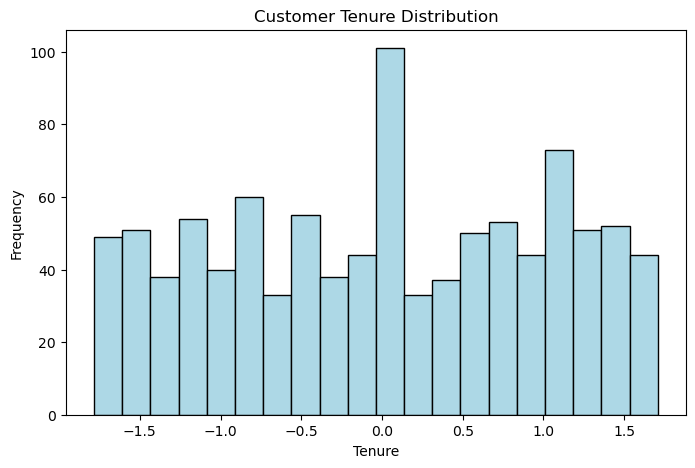

In [11]:
plt.figure(figsize=(8,5))

plt.hist(df['tenure'], bins=20,color='lightblue',edgecolor='black')

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure")
plt.ylabel("Frequency")

plt.show()

# Correlation Heatmap

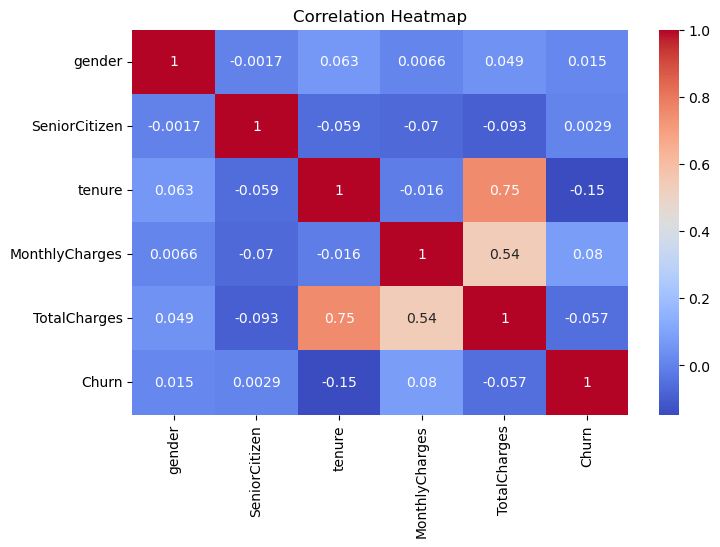

In [15]:
plt.figure(figsize=(8, 5))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

# Count Plot

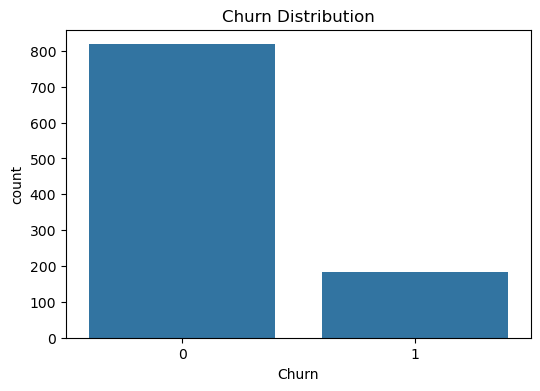

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(x='Churn', data=df)

plt.title("Churn Distribution")

plt.show()

# Feature Selection

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Churn'] = le.fit_transform(df['Churn'])

print(df['Churn'].unique())

[0 1]


## Train-Test Split

The dataset is divided into:
- Training Data (80%)
- Testing Data (20%)

This helps evaluate model performance on unseen data.

In [24]:
# Convert all remaining categorical columns to dummy variables
df = pd.get_dummies(
    df,
    columns=[
        'Partner',
        'Dependents',
        'PhoneService',
        'InternetService',
        'PaperlessBilling',
        'PaymentMethod'
    ],
    drop_first=True
)

print(df.head())
print(df.dtypes)

   gender  SeniorCitizen    tenure  MonthlyCharges  TotalCharges  Churn  \
0       1              0  0.970519        0.297461      0.975854      0   
1       0              0  1.708241       -1.548151     -0.417445      0   
2       1              0 -1.488557        1.157848     -0.997390      1   
3       1              0  0.921337        0.209862      0.878238      0   
4       1              0  1.462334        0.594305      1.677565      0   

   Contract_One year  Contract_Two year  Partner_Yes  Dependents_Yes  \
0              False               True        False            True   
1               True              False        False            True   
2              False              False        False           False   
3              False              False        False            True   
4              False              False         True            True   

   PhoneService_Yes  InternetService_Fiber optic  InternetService_No  \
0              True                         

# Train-Test Split

In [25]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (800, 16)
Testing Shape: (200, 16)


## 3. Logistic Regression Model

Logistic Regression uses the sigmoid function to predict probabilities between 0 and 1.

# Train Model

In [26]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


# Model Coefficients

In [27]:
print("Coefficients:")
print(model.coef_)

print("\nIntercept:")
print(model.intercept_)

Coefficients:
[[ 4.77030177e-02 -6.79287380e-02 -6.30598674e-01  8.57231420e-02
   3.36096629e-01 -1.74826497e+00 -1.52386528e+00 -5.05879110e-01
  -1.06878146e-03  6.68292392e-02  1.12456791e+00 -6.98588696e-03
  -8.51459514e-02  1.38751088e-02  4.53741789e-01  9.29588742e-02]]

Intercept:
[-1.53199594]


# Predictions

In [29]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

results.head(10)

,Actual,Predicted
521,0,0
737,0,0
740,0,0
660,0,0
411,0,0
678,0,0
626,0,0
513,1,1
859,0,0
136,0,0


# Confusion Matrix

In [30]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[162   2]
 [ 29   7]]


# Confusion Matrix Visualization

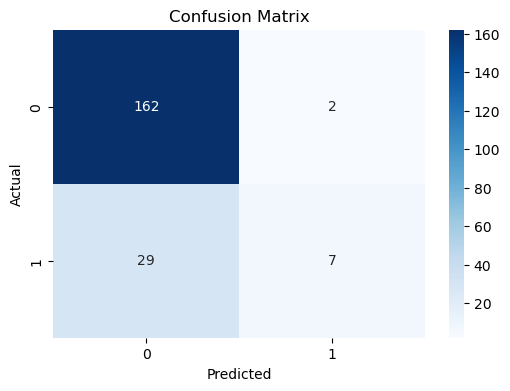

In [31]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

## 4. Model Evaluation

The following metrics are used:
- Accuracy
- Precision
- Recall
- F1-Score

# Accuracy

In [34]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.845


# Precision

In [35]:
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.7777777777777778


# Recall

In [36]:
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.19444444444444445


# F1-Score

In [37]:
f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.3111111111111111


## Conclusion

- Customer churn prediction was successfully performed.
- Logistic Regression was used for classification.
- Model performance was evaluated using Accuracy, Precision, Recall, and F1-Score.
- The model can be improved using Random Forest, feature engineering, and hyperparameter tuning.